# 16b — VAE Training & Evaluation — Helpdesk

Trains the LSTM-VAE (feasibility model) using constraints from notebook 16a.
Includes debug cells for inspecting VAE samples, reconstructions, latent perturbations,
and constraint satisfaction rates.

In [1]:
import sys
import os
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent

if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))

# src/ must be on sys.path for torch.load to unpickle event_log_loader classes
src_path = str(_current / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

In [2]:
# ===== TEST MODE =====
TEST_MODE = False
TEST_N_SEQUENCES = 600

In [3]:
import torch
from tqdm.auto import tqdm

with tqdm(total=3, desc='Loading data & model') as pbar:
    # --- Load TRAINING dataset (for VAE training) ---
    pbar.set_postfix_str('loading training dataset...')
    train_data_path = _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_train.pkl'
    train_dataset = torch.load(train_data_path, weights_only=False)
    pbar.update(1)

    # --- Load TEST dataset (for evaluation / counterfactual generation) ---
    pbar.set_postfix_str('loading test dataset...')
    test_data_path = _current / 'encoded_data' / 'test_philipp' / 'helpdesk_all_5_test.pkl'
    test_dataset = torch.load(test_data_path, weights_only=False)
    pbar.update(1)

    # --- Load trained prediction model ---
    pbar.set_postfix_str('loading prediction model...')
    from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM

    model_path = _current / 'src' / 'notebooks' / 'training_variational_dropout' / 'Helpdesk' / 'Helpdesk_full_grad_norm_new_4layer.pkl'
    model = DropoutUncertaintyEncoderDecoderLSTM.load(str(model_path), dropout=0.0)
    model.eval()
    pbar.update(1)
    pbar.set_postfix_str('done')

sample = train_dataset[0]
n_cat = len(sample[0])
n_num = len(sample[1])
seq_len = sample[0][0].shape[0]
print(f'Train dataset: {len(train_dataset)} sequences')
print(f'Test dataset:  {len(test_dataset)} sequences')
print(f'Features: {n_cat} cat, {n_num} num, seq_len={seq_len}')
print(f'Model loaded: {sum(p.numel() for p in model.parameters()):,} parameters')

Loading data & model:   0%|          | 0/3 [00:00<?, ?it/s]

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('VariantIndex', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '12

In [4]:
from src.interpretability.utils.tensor_decoder import TensorDecoder

decoder = TensorDecoder(train_dataset)

ACTIVITY_FEATURE = 'Activity'
activity_idx_to_label = decoder.idx_to_label[ACTIVITY_FEATURE]
max_idx = max(activity_idx_to_label.keys())
activity_names = [activity_idx_to_label.get(i, f'<unk_{i}>') for i in range(max_idx + 1)]
eos_idx = next(i for i, name in enumerate(activity_names) if name == 'EOS')

print(f'Activity vocabulary ({len(activity_names)}), EOS={eos_idx}')

Activity vocabulary (16), EOS=5


In [5]:
from src.interpretability.perturbation_methods import RevisedPlus, RevisedPlusConfig, create_revised_plus_for_model
import random

device = 'cpu'

# === FULL TRAINING ===
QUICK_TEST = False
VAE_MAX_SEQUENCES = 25_000
VAE_EPOCHS = 100

if len(train_dataset) > VAE_MAX_SEQUENCES:
    indices = random.sample(range(len(train_dataset)), VAE_MAX_SEQUENCES)
    vae_dataset = [train_dataset[i] for i in indices]
    print(f'VAE training subset: {len(vae_dataset)} sequences (sampled from {len(train_dataset)})')
else:
    vae_dataset = list(train_dataset)
    print(f'VAE training on full train set: {len(vae_dataset)} sequences')

config = RevisedPlusConfig(
    # Architecture (Stevens et al. 2024, Table hyperparams)
    vae_encoder_hidden=50,     # hidden_dim1
    vae_decoder_hidden=50,     # decoder LSTM (same as encoder)
    vae_latent_dim=20,         # hidden_dim2 (bottleneck)
    vae_num_layers=2,          # lstm_size
    vae_dropout=0.3,           # dropout
    # Training
    vae_epochs=VAE_EPOCHS,
    vae_batch_size=128,
    vae_kl_weight=0.1,
    vae_lr=1e-3,               # learning rate
    vae_grad_clip=0.25,
    vae_weight_decay=1e-5,
    # Search
    n_candidates_per_round=200,
    n_search_rounds=5,
    top_k=5,
    min_plausibility=0.0,
    device=device,
    activity_feature=ACTIVITY_FEATURE,
)

vae_path = str(_current / 'encoded_data' / 'helpdesk_vae.pkl')

rp = create_revised_plus_for_model(
    model=model,
    dataset=vae_dataset,
    activity_names=activity_names,
    config=config,
    vae_path=vae_path,
    constraints=set(),
)
print(f'\nVAE ready ({sum(p.numel() for p in rp.vae.parameters()):,} parameters)')
print(f'  Encoder: BiLSTM {config.vae_num_layers}L x {config.vae_encoder_hidden}h')
print(f'  Decoder: LSTM {config.vae_num_layers}L x {config.vae_decoder_hidden}h')
print(f'  Latent:  {config.vae_latent_dim}d')

/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:163: DeprecationWarning: module 'sre_parse' is deprecated
  import sre_parse
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/lark/utils.py:164: DeprecationWarning: module 'sre_constants' is deprecated
  import sre_constants


VAE training on full train set: 19872 sequences
Using 0 pre-mined constraints (0 prefix-safe, 0 with data conditions)


Training VAE:   0%|          | 0/100 [00:00<?, ?it/s]

  Epoch 1/100:   0%|          | 0/156 [00:00<?, ?it/s]

  Epoch 2/100:   0%|          | 0/156 [00:00<?, ?it/s]

...

  Epoch 97/100:   0%|          | 0/156 [00:00<?, ?it/s]

  Epoch 98/100:   0%|          | 0/156 [00:00<?, ?it/s]

  Epoch 99/100:   0%|          | 0/156 [00:00<?, ?it/s]

  Epoch 100/100:   0%|          | 0/156 [00:00<?, ?it/s]

VAE saved to /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/encoded_data/helpdesk_vae.pkl

VAE ready (293,978 parameters)
  Encoder: BiLSTM 2L x 50h
  Decoder: LSTM 2L x 50h
  Latent:  20d


DEBUG:matplotlib:CACHEDIR=/Users/philippeichhorn/.matplotlib
DEBUG:matplotlib.font_manager:Using fontManager instance from /Users/philippeichhorn/.matplotlib/fontlist-v390.json
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.pyplot:Loaded backend module://matplotlib_inline.backend_inline version unknown.
DEBUG:matplotlib.font_manager:findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-BoldItalic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=700, stretch='normal', size='scalable')) = 11.335
DEBUG:matplotlib.font_manager:findfont: score(FontEntry(fname='/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix

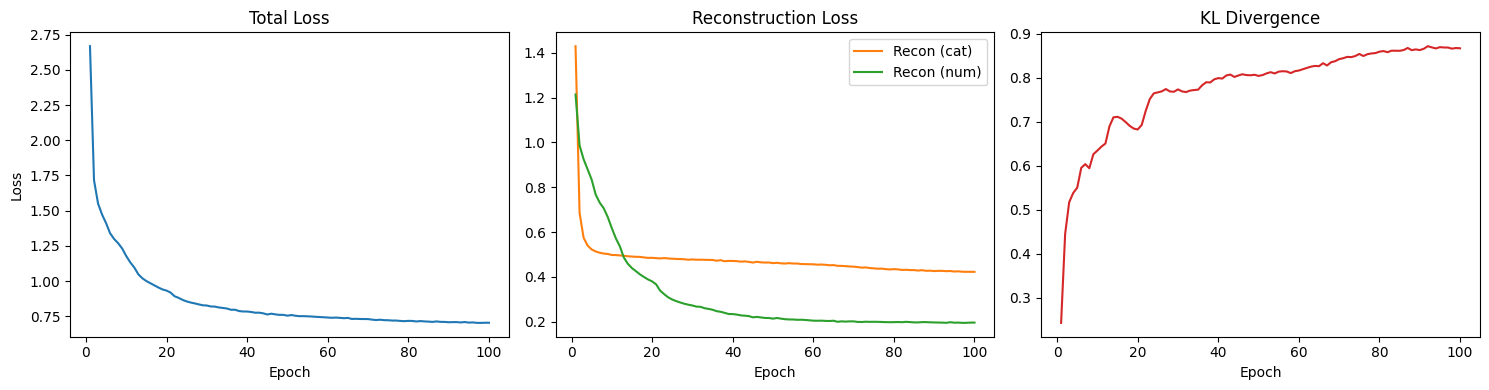

Final losses: total=0.7048, recon_cat=0.4223, recon_num=0.1958, kl=0.8673


In [6]:
# === Training loss curves ===
import matplotlib.pyplot as plt

history = rp.train_history if hasattr(rp, 'train_history') else None
if history:
    epochs = range(1, len(history) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(epochs, [h['total'] for h in history], label='Total')
    axes[0].set_title('Total Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')

    axes[1].plot(epochs, [h['recon_cat'] for h in history], label='Recon (cat)', color='tab:orange')
    axes[1].plot(epochs, [h['recon_num'] for h in history], label='Recon (num)', color='tab:green')
    axes[1].set_title('Reconstruction Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    axes[2].plot(epochs, [h['kl'] for h in history], label='KL', color='tab:red')
    axes[2].set_title('KL Divergence')
    axes[2].set_xlabel('Epoch')

    plt.tight_layout()
    plt.show()

    print(f"Final losses: total={history[-1]['total']:.4f}, "
          f"recon_cat={history[-1]['recon_cat']:.4f}, "
          f"recon_num={history[-1]['recon_num']:.4f}, "
          f"kl={history[-1]['kl']:.4f}")
else:
    print('No training history (VAE was loaded from cache)')

In [7]:
# === Debug: VAE samples from prior ===

def _act_seq(tensor):
    """Convert activity tensor to list of names, stripping padding."""
    return [activity_names[x.item()] for x in tensor if x.item() != 0]

vae = rp.vae
vae.eval()
dev = next(vae.parameters()).device

print('=' * 80)
print('VAE SAMPLES FROM PRIOR (z ~ N(0,1))')
print('=' * 80)
with torch.no_grad():
    cat_sampled, num_sampled = vae.sample(10, device=dev)
for i in range(10):
    seq = _act_seq(cat_sampled[0][i])
    print(f'  Sample {i+1:2d} (len={len(seq):2d}): {" -> ".join(seq)}')

VAE SAMPLES FROM PRIOR (z ~ N(0,1))
  Sample  1 (len= 3): Assign seriousness -> Take in charge ticket -> Resolve ticket
  Sample  2 (len= 9): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EOS -> EOS -> EOS -> EOS -> EOS
  Sample  3 (len= 4): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed
  Sample  4 (len= 6): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EOS -> EOS
  Sample  5 (len= 5): Assign seriousness -> Take in charge ticket -> Take in charge ticket -> Resolve ticket -> Closed
  Sample  6 (len= 6): Assign seriousness -> Take in charge ticket -> Take in charge ticket -> Wait -> Take in charge ticket -> Resolve ticket
  Sample  7 (len= 3): Assign seriousness -> Take in charge ticket -> Resolve ticket
  Sample  8 (len=12): Assign seriousness -> Take in charge ticket -> Wait -> Take in charge ticket -> Resolve ticket -> Closed -> EOS -> EOS -> EOS -> EOS -> EOS -> EOS
  Sample  9 (len= 3): Assign seriou

In [8]:
# === Debug: VAE reconstructions (on TEST data) ===
print('=' * 80)
print('VAE RECONSTRUCTIONS on TEST SET (encode -> mu -> decode)')
print('=' * 80)

def _left_to_right(cat_tuple, num_tuple, seq_len):
    """Convert left-padded dataset sample to right-padded tensors for VAE."""
    prefix_len = int((cat_tuple[0] != 0).sum().item())
    event_start = seq_len - prefix_len
    cat_rp = []
    for c in cat_tuple:
        t = torch.zeros_like(c)
        t[:prefix_len] = c[event_start:]
        cat_rp.append(t.unsqueeze(0))
    num_stacked = torch.stack(num_tuple, dim=-1)
    num_rp = torch.zeros_like(num_stacked).unsqueeze(0)
    num_rp[0, :prefix_len] = num_stacked[event_start:]
    return cat_rp, num_rp

n_show = min(10, len(test_dataset))
for i in range(n_show):
    cat_tuple, num_tuple, case_id = test_dataset[i]
    cat_rp, num_rp = _left_to_right(cat_tuple, num_tuple, seq_len)
    cat_in = [c.to(dev) for c in cat_rp]
    num_in = num_rp.to(dev)

    orig_seq = _act_seq(cat_tuple[0])

    with torch.no_grad():
        cat_recon, _ = vae.reconstruct(cat_in, num_in)
    recon_seq = _act_seq(cat_recon[0][0])

    match = orig_seq == recon_seq
    print(f'  Case {i+1:2d} ({"MATCH" if match else "DIFF"}):')
    print(f'    Original (len={len(orig_seq):2d}): {" -> ".join(orig_seq)}')
    if not match:
        print(f'    Recon    (len={len(recon_seq):2d}): {" -> ".join(recon_seq)}')

VAE RECONSTRUCTIONS on TEST SET (encode -> mu -> decode)
  Case  1 (MATCH):
    Original (len= 5): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EOS
  Case  2 (MATCH):
    Original (len= 6): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EOS -> EOS
  Case  3 (MATCH):
    Original (len= 7): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EOS -> EOS -> EOS
  Case  4 (MATCH):
    Original (len= 8): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EOS -> EOS -> EOS -> EOS
  Case  5 (MATCH):
    Original (len= 9): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EOS -> EOS -> EOS -> EOS -> EOS
  Case  6 (MATCH):
    Original (len= 9): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EOS -> EOS -> EOS -> EOS -> EOS
  Case  7 (MATCH):
    Original (len= 5): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EO

In [9]:
# === Debug: Latent perturbations (on TEST data) ===
print('=' * 80)
print('LATENT PERTURBATIONS on TEST SET (encode -> z + noise -> decode)')
print('=' * 80)
cat_tuple, num_tuple, _ = test_dataset[0]
cat_rp, num_rp = _left_to_right(cat_tuple, num_tuple, seq_len)
cat_in = [c.to(dev) for c in cat_rp]
num_in = num_rp.to(dev)
orig_seq = _act_seq(cat_tuple[0])
print(f'  Original (len={len(orig_seq):2d}): {" -> ".join(orig_seq)}')

with torch.no_grad():
    mu, logvar = vae.encode(cat_in, num_in)
    for noise_scale in [0.1, 0.5, 1.0, 2.0]:
        z = mu + noise_scale * torch.randn_like(mu)
        cat_logits, _ = vae.decode(z)
        cat_decoded = [l.argmax(dim=-1) for l in cat_logits]
        perturbed_seq = _act_seq(cat_decoded[0][0])
        print(f'  noise={noise_scale:.1f} (len={len(perturbed_seq):2d}): {" -> ".join(perturbed_seq)}')

LATENT PERTURBATIONS on TEST SET (encode -> z + noise -> decode)
  Original (len= 5): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EOS
  noise=0.1 (len= 5): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EOS
  noise=0.5 (len= 4): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed
  noise=1.0 (len= 6): Assign seriousness -> Resolve ticket -> Closed -> EOS -> EOS -> EOS
  noise=2.0 (len= 6): Assign seriousness -> Take in charge ticket -> Resolve ticket -> Closed -> EOS -> EOS


In [10]:
# === Evaluate constraint satisfaction on generated samples ===
from src.interpretability.perturbation_methods import DeclareConstraintChecker
import numpy as np
import pickle
from tqdm.auto import tqdm

# Load constraints from notebook 16a output
constraints_pkl_path = _current / 'encoded_data' / 'helpdesk_constraints.pkl'
with open(constraints_pkl_path, 'rb') as f:
    constraints_data = pickle.load(f)

all_constraints = constraints_data['all']
prefix_safe_constraints = constraints_data['prefix_safe']
sequence_constraints = constraints_data['sequence']

print('=' * 80)
print(f'CONSTRAINT SATISFACTION ON VAE SAMPLES ({len(all_constraints)} constraints)')
print('=' * 80)

n_eval = 100
with torch.no_grad():
    cat_sampled, _ = vae.sample(n_eval, device=dev)

constraint_sets = {
    'prefix_safe': prefix_safe_constraints,
    'sequence': sequence_constraints,
    'all': all_constraints,
}

for set_name, cset in tqdm(constraint_sets.items(), desc='Evaluating constraint sets'):
    if not cset:
        print(f'\n  {set_name}: (no constraints)')
        continue
    rates = []
    for i in range(n_eval):
        seq = [x.item() for x in cat_sampled[0][i] if x.item() != 0]
        rate = DeclareConstraintChecker.satisfaction_rate(seq, cset)
        rates.append(rate)
    rates = np.array(rates)
    print(f'\n  {set_name} ({len(cset)} constraints):')
    print(f'    Mean satisfaction: {rates.mean():.1%}')
    print(f'    Fully satisfied:   {(rates == 1.0).mean():.1%}')
    print(f'    Min satisfaction:  {rates.min():.1%}')

    # Per-constraint violation rates
    n_violations = {}
    for c in tqdm(cset, desc=f'  Checking {set_name} violations', leave=False):
        count = 0
        for i in range(n_eval):
            seq = [x.item() for x in cat_sampled[0][i] if x.item() != 0]
            if not DeclareConstraintChecker.check(seq, c):
                count += 1
        if count > 0:
            n_violations[c] = count
    if n_violations:
        print(f'    Most violated:')
        for c, count in sorted(n_violations.items(), key=lambda x: -x[1])[:5]:
            print(f'      {c.format(activity_names)}: {count}/{n_eval} ({count/n_eval:.0%})')

CONSTRAINT SATISFACTION ON VAE SAMPLES (23 constraints)


Evaluating constraint sets:   0%|          | 0/3 [00:00<?, ?it/s]


  prefix_safe (16 constraints):
    Mean satisfaction: 100.0%
    Fully satisfied:   100.0%
    Min satisfaction:  100.0%


  Checking prefix_safe violations:   0%|          | 0/16 [00:00<?, ?it/s]


  sequence (7 constraints):
    Mean satisfaction: 80.3%
    Fully satisfied:   42.0%
    Min satisfaction:  42.9%


  Checking sequence violations:   0%|          | 0/7 [00:00<?, ?it/s]

    Most violated:
      response(Assign seriousness, Closed): 58/100 (58%)
      response(Assign seriousness, Resolve ticket): 38/100 (38%)
      response(Resolve ticket, Closed): 20/100 (20%)
      response(Wait, Closed): 13/100 (13%)
      response(Wait, Resolve ticket): 9/100 (9%)

  all (23 constraints):
    Mean satisfaction: 94.0%
    Fully satisfied:   42.0%
    Min satisfaction:  82.6%


  Checking all violations:   0%|          | 0/23 [00:00<?, ?it/s]

    Most violated:
      response(Assign seriousness, Closed): 58/100 (58%)
      response(Assign seriousness, Resolve ticket): 38/100 (38%)
      response(Resolve ticket, Closed): 20/100 (20%)
      response(Wait, Closed): 13/100 (13%)
      response(Wait, Resolve ticket): 9/100 (9%)


In [11]:
# Save trained VAE to pkl
if vae_path and Path(vae_path).exists():
    print(f'VAE already saved at {vae_path}')
elif vae_path:
    torch.save(rp.vae.cpu(), vae_path)
    rp.vae = rp.vae.to(dev)
    print(f'VAE saved to {vae_path}')
else:
    print('Quick test mode — VAE not saved.')

VAE already saved at /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/encoded_data/helpdesk_vae.pkl
